In [7]:
# ==========================================
# UEBA Challenge - Problema 1 (A + B)
# Autor: Alexis Pacek
# ==========================================

# ==========================================
# 📦 1. Imports
# ==========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest
from sklearn.metrics import classification_report, roc_auc_score

# ==========================================
# 📥 2. Carga de datos
# ==========================================
df = pd.read_csv(r'src\data\user_logins.csv')

df['login_time'] = pd.to_datetime(df['login_time'])
df = df.sort_values(['user_id', 'login_time'])

# ==========================================
# 🔍 3. Feature Engineering
# ==========================================

# Proceso a agregar features comunes en la literatura de este problema


#agregar hora
# importancia: detectar comportamientos de uso horario
df['hour'] = df['login_time'].dt.hour
df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
df['hour_cos'] = np.cos(2*np.pi*df['hour']/24)

# ------------------------------
# Velocidad de login
# ------------------------------
# Importancia: detectar actividad automatizada o sospechosa

df['time_diff'] = df.groupby('user_id')['login_time'].diff().dt.total_seconds()
df['time_diff'] = df['time_diff'].fillna(df['time_diff'].median())
df['time_diff_log'] = np.log1p(df['time_diff'])

df['login_velocity'] = 1 / (df['time_diff'] + 1)

# ------------------------------
# 🌐 3.3 Rareza de IP
# ------------------------------
# Importancia: detectar IPs poco frecuentes

ip_counts = df.groupby(['user_id','ip_address']).size()
ip_freq = ip_counts / ip_counts.groupby(level=0).transform('sum')
df = df.join(ip_freq.rename('ip_freq'), on=['user_id','ip_address'])
df['ip_rarity'] = 1 - df['ip_freq']

# ------------------------------
# 💻 3.4 Rareza de dispositivo
# ------------------------------

device_counts = df.groupby(['user_id','device_type']).size()
device_freq = device_counts / device_counts.groupby(level=0).transform('sum')
df = df.join(device_freq.rename('device_freq'), on=['user_id','device_type'])
df['device_rarity'] = 1 - df['device_freq']

# ------------------------------
# 🔁 3.5 Cambios de contexto
# ------------------------------

df['ip_change'] = (df['ip_address'] != df.groupby('user_id')['ip_address'].shift()).astype(int)
df['device_change'] = (df['device_type'] != df.groupby('user_id')['device_type'].shift()).astype(int)

# ------------------------------
# 📊 3.6 Desvío horario real
# ------------------------------

mean_sin = df.groupby('user_id')['hour_sin'].transform('mean')
mean_cos = df.groupby('user_id')['hour_cos'].transform('mean')

df['hour_deviation'] = np.sqrt((df['hour_sin']-mean_sin)**2 + (df['hour_cos']-mean_cos)**2)




In [8]:
df.isnull().sum()

user_id           0
login_time        0
ip_address        0
device_type       0
hour              0
hour_sin          0
hour_cos          0
time_diff         0
time_diff_log     0
login_velocity    0
ip_freq           0
ip_rarity         0
device_freq       0
device_rarity     0
ip_change         0
device_change     0
hour_deviation    0
dtype: int64


📊 Feature: time_diff_log

➡️ Estadísticas:
count    18941.000000
mean         9.682314
std          2.305874
min          0.000000
25%          8.583168
50%         10.389641
75%         11.343571
max         13.578751
Name: time_diff_log, dtype: float64

➡️ Percentiles:
0.01     0.000000
0.05     5.198497
0.50    10.389641
0.95    12.154890
0.99    12.701162
Name: time_diff_log, dtype: float64


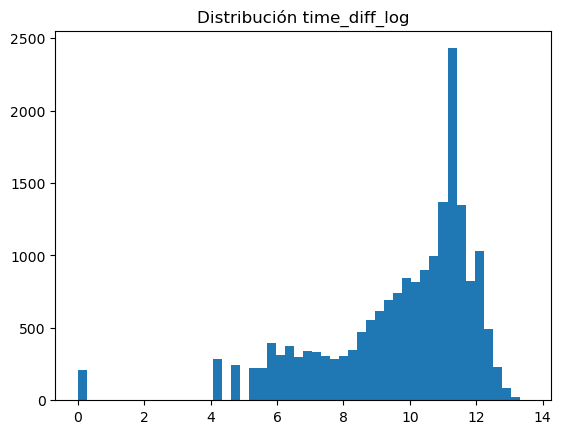


📊 Feature: login_velocity

➡️ Estadísticas:
count    18941.000000
mean         0.011581
std          0.103673
min          0.000001
25%          0.000012
50%          0.000031
75%          0.000187
max          1.000000
Name: login_velocity, dtype: float64

➡️ Percentiles:
0.01    0.000003
0.05    0.000005
0.50    0.000031
0.95    0.005525
0.99    1.000000
Name: login_velocity, dtype: float64


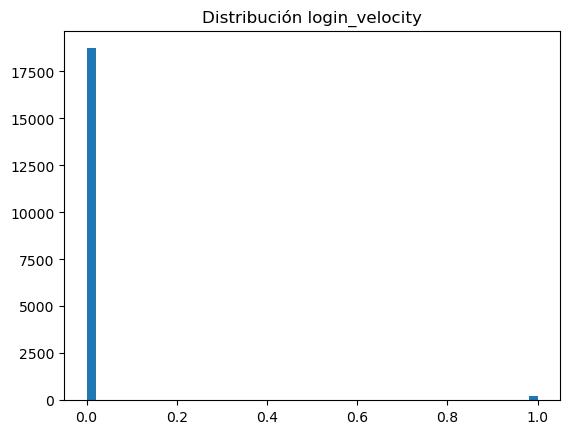


📊 Feature: ip_rarity

➡️ Estadísticas:
count    18941.000000
mean         0.489151
std          0.322248
min          0.174863
25%          0.250000
50%          0.324607
75%          0.974747
max          0.995726
Name: ip_rarity, dtype: float64

➡️ Percentiles:
0.01    0.191781
0.05    0.207254
0.50    0.324607
0.95    0.995025
0.99    0.995370
Name: ip_rarity, dtype: float64


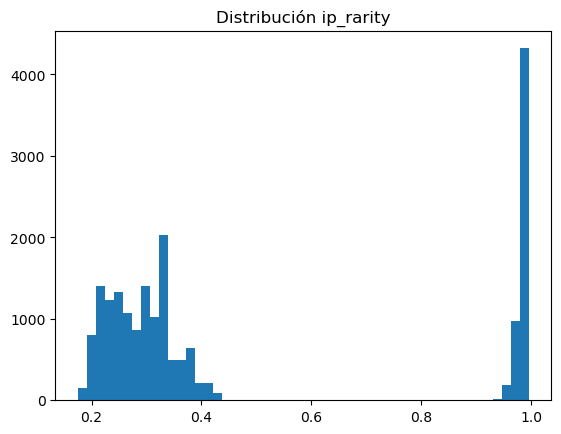


📊 Feature: device_rarity

➡️ Estadísticas:
count    18941.000000
mean         0.657600
std          0.053292
min          0.537313
25%          0.616352
50%          0.654255
75%          0.691542
max          0.804878
Name: device_rarity, dtype: float64

➡️ Percentiles:
0.01    0.545455
0.05    0.570552
0.50    0.654255
0.95    0.752427
0.99    0.787356
Name: device_rarity, dtype: float64


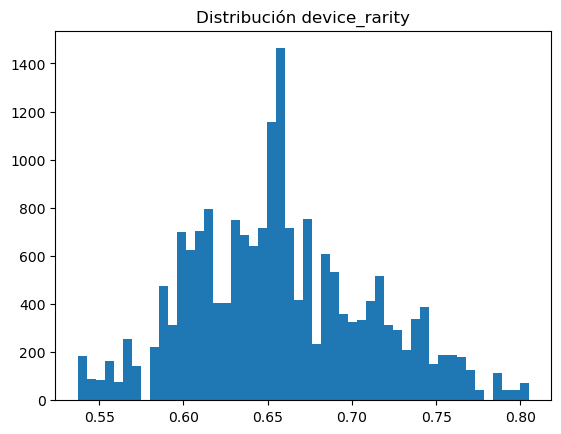


📊 Feature: hour_deviation

➡️ Estadísticas:
count    18941.000000
mean         0.789541
std          0.329175
min          0.130715
25%          0.546010
50%          0.854522
75%          1.017614
max          1.873771
Name: hour_deviation, dtype: float64

➡️ Percentiles:
0.01    0.132229
0.05    0.193713
0.50    0.854522
0.95    1.245247
0.99    1.576696
Name: hour_deviation, dtype: float64


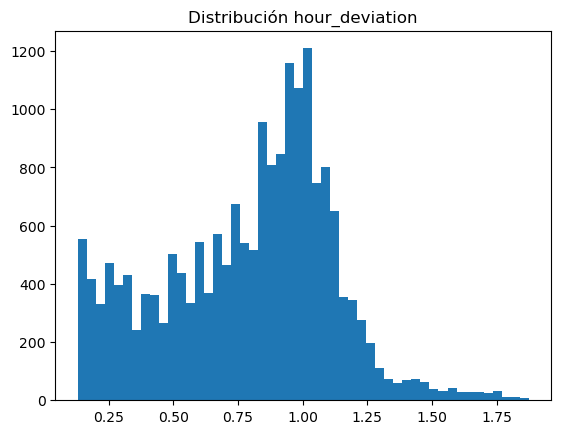


📊 Feature: ip_change

➡️ Estadísticas:
count    18941.000000
mean         0.465445
std          0.498818
min          0.000000
25%          0.000000
50%          0.000000
75%          1.000000
max          1.000000
Name: ip_change, dtype: float64

➡️ Percentiles:
0.01    0.0
0.05    0.0
0.50    0.0
0.95    1.0
0.99    1.0
Name: ip_change, dtype: float64


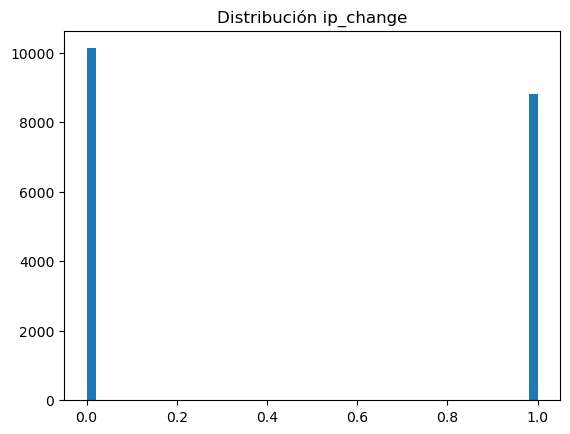


📊 Feature: device_change

➡️ Estadísticas:
count    18941.000000
mean         0.584182
std          0.492875
min          0.000000
25%          0.000000
50%          1.000000
75%          1.000000
max          1.000000
Name: device_change, dtype: float64

➡️ Percentiles:
0.01    0.0
0.05    0.0
0.50    1.0
0.95    1.0
0.99    1.0
Name: device_change, dtype: float64


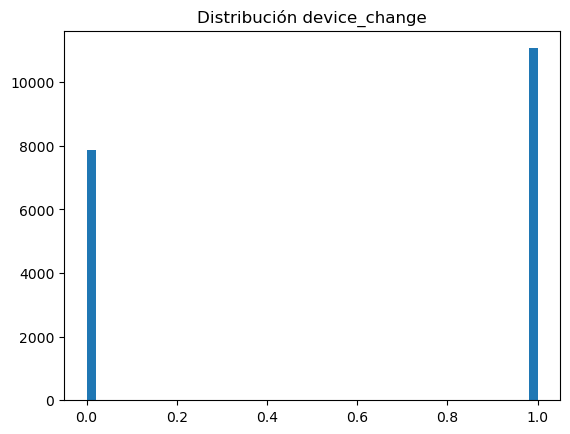

In [9]:
features = [
    'time_diff_log',
    'login_velocity',
    'ip_rarity',
    'device_rarity',
    'hour_deviation',
    'ip_change',
    'device_change'
]

for f in features:
    print(f"\n============================")
    print(f"📊 Feature: {f}")
    print("============================")
    
    print("\n➡️ Estadísticas:")
    print(df[f].describe())
    
    print("\n➡️ Percentiles:")
    print(df[f].quantile([0.01,0.05,0.5,0.95,0.99]))
    
    plt.figure()
    plt.hist(df[f], bins=50)
    plt.title(f'Distribución {f}')
    plt.show()

Comentarios:

1) time_diff_log

Mediana ≈ 10.38 → log(≈ 32k seg ≈ 9h)
P5 = 5.2 → log(≈ 180 seg ≈ 3 min)
Tiene cola hacia valores bajos

La mayoría de los usuarios loguea cada varias horas
Logins muy rápidos (< pocos minutos) son raros

Feature MUY útil, voy a usar percentil bajo

-----------

2) login_velocity (VELOCIDAD)


P50 ≈ 0.00003
P99 = 1.0 


Está dominada por outliers extremos, inestable, feature debil

-----------

3) ip_rarity 

Media ≈ 0.49
P75 ≈ 0.97
P95 ≈ 0.995

buena pinta la distribuciòn 

Hay IPs muy frecuentes (baja rareza)
muchas IPs casi únicas (alta rareza)



la voy usar, P95 como threshold 

-----------

4) device_rarity

Rango muy chico: 0.53 → 0.80
Desvío bajo
Distribución compacta


No hay eventos extremos, Feature poco discriminativa

-----------

5. hour_deviation (MUY BUENA)

Buena dispersión
P95 ≈ 1.24
P99 ≈ 1.57

Hay un patrón horario claro por usuario
Algunos logins están claramente fuera del patrón

Feature FUERTE

usarè percentil alto (p95)

-----------
6) ip_change

muy balanceada, Cambiar IP es común, No implica anomalía por sí solo

-----------

7) device_change


Cambiar device es NORMAL,No discrimina anomalías, Feature muy débil

-----------

RESUMEN FINAL:

Features FUERTES
ip_rarity (la mejor)
hour_deviation
time_diff_log

Features MEDIAS
ip_change (solo combinada)
device_rarity

Features MALAS
login_velocity
device_change

In [ ]:
df.head()

In [10]:
# intento geolocalizaciòn
import ipaddress

def is_private_ip(ip):
    try:
        return ipaddress.ip_address(ip).is_private
    except:
        return True

df['is_private_ip'] = df['ip_address'].apply(is_private_ip)
df['is_private_ip'].mean()

# se observa que un 97% de las ip son privadas por lo tanto no voy a poder triangular su ubicaciòn con GeoLite2

df = df.drop(columns=['is_private_ip'])

In [11]:
# busco detectar ips compartidas
ip_user_count = df.groupby('ip_address')['user_id'].nunique()
df = df.join(ip_user_count.rename('ip_user_count'), on='ip_address')


➡️ Estadísticas:
count    18941.000000
mean        19.295919
std          8.265283
min          1.000000
25%         16.000000
50%         21.000000
75%         25.000000
max         30.000000
Name: ip_user_count, dtype: float64

➡️ Percentiles:
0.01     1.0
0.05     1.0
0.50    21.0
0.95    29.0
0.99    30.0
Name: ip_user_count, dtype: float64


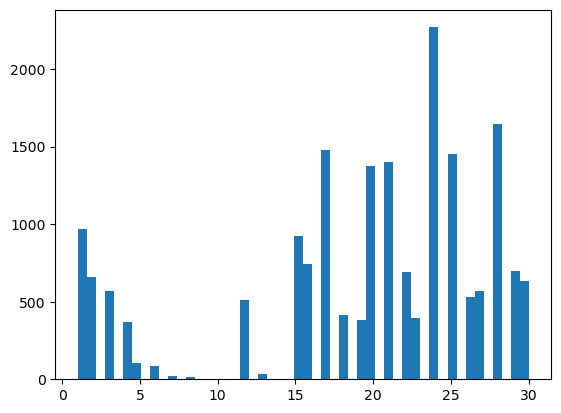

In [12]:
print("\n➡️ Estadísticas:")
print(df['ip_user_count'].describe())
    
print("\n➡️ Percentiles:")
print(df['ip_user_count'].quantile([0.01,0.05,0.5,0.95,0.99]))
    
plt.figure()
plt.hist(df['ip_user_count'], bins=50)
plt.show()

In [13]:
# lo "normal" es que los usuarios compartan muchas ips, lo raro son los ùnicos
# 
df['ip_is_rare'] = (df['ip_user_count'] <= 1).astype(int)
df['ip_is_massive'] = (df['ip_user_count'] >= df['ip_user_count'].quantile(0.95)).astype(int)

df['suspicious_ip'] = (
    (df['ip_rarity'] > df['ip_rarity'].quantile(0.95)) &
    (df['ip_user_count'] <= 2)
)

df['ip_rarity_p95_user'] = df.groupby('user_id')['ip_rarity'].transform(lambda x: x.quantile(0.95))

df['rule_ip'] = (df['ip_rarity'] > df['ip_rarity_p95_user']).astype(int)

In [14]:
features = [
    'time_diff_log',
    'ip_rarity',
    'hour_deviation',
    'device_rarity'
]
# Definir percentiles para features relevantes
p95_rarity = df['ip_rarity'].quantile(0.95)
p5_time_diff = df['time_diff'].quantile(0.05)
p95_hour = df['hour_deviation'].quantile(0.95)

df['rule_ip'] = (df['ip_rarity'] > p95_rarity)
df['rule_time'] = (df['time_diff'] < p5_time_diff)
df['rule_hour'] = (df['hour_deviation'] > p95_hour)

# combinaciones
df['rule_combo'] = df['ip_change'] & df['rule_ip']

In [ ]:
# ==========================================
# 🧪 UEBA Challenge - Problema 1 (A + B)
# Versión FINAL - Lista para entrega
# Autor: Alexis Pacek
# ==========================================

# ==========================================
# 📦 1. Imports
# ==========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest
from sklearn.metrics import classification_report

# ==========================================
# 📥 2. Carga de datos
# ==========================================
df = pd.read_csv(r'src\data\user_logins.csv')

df['login_time'] = pd.to_datetime(df['login_time'])
df = df.sort_values(['user_id', 'login_time'])

# ==========================================
# 🔍 3. Feature Engineering
# ==========================================

# ------------------------------
# ⏰ Temporal
# ------------------------------
df['hour'] = df['login_time'].dt.hour
df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)

# ------------------------------
# ⚡ Tiempo entre logins
# ------------------------------
df['time_diff'] = df.groupby('user_id')['login_time'].diff().dt.total_seconds()
df['time_diff'] = df['time_diff'].fillna(df['time_diff'].median())
df['time_diff_log'] = np.log1p(df['time_diff'])

# ------------------------------
# 🌐 Rareza de IP
# ------------------------------
ip_counts = df.groupby(['user_id','ip_address']).size()
ip_freq = ip_counts / ip_counts.groupby(level=0).transform('sum')
df = df.join(ip_freq.rename('ip_freq'), on=['user_id','ip_address'])
df['ip_rarity'] = 1 - df['ip_freq']

# ------------------------------
# 💻 Rareza de dispositivo
# ------------------------------
device_counts = df.groupby(['user_id','device_type']).size()
device_freq = device_counts / device_counts.groupby(level=0).transform('sum')
df = df.join(device_freq.rename('device_freq'), on=['user_id','device_type'])
df['device_rarity'] = 1 - df['device_freq']

# ------------------------------
# 🔁 Cambios de contexto
# ------------------------------
df['ip_change'] = (df['ip_address'] != df.groupby('user_id')['ip_address'].shift()).astype(int)

# ------------------------------
# 📊 Desvío horario
# ------------------------------
mean_sin = df.groupby('user_id')['hour_sin'].transform('mean')
mean_cos = df.groupby('user_id')['hour_cos'].transform('mean')

df['hour_deviation'] = np.sqrt((df['hour_sin']-mean_sin)**2 + (df['hour_cos']-mean_cos)**2)

# ------------------------------
# 🌐 IP compartidas
# ------------------------------
ip_user_count = df.groupby('ip_address')['user_id'].nunique()
df = df.join(ip_user_count.rename('ip_user_count'), on='ip_address')

# ==========================================
# 🧠 4. Features derivadas (CLAVE)
# ==========================================

# Percentiles por usuario
p90_ip = df.groupby('user_id')['ip_rarity'].transform(lambda x: x.quantile(0.90))
p5_time = df.groupby('user_id')['time_diff'].transform(lambda x: x.quantile(0.05))

# Anomalías

df['ip_anomaly'] = ((df['ip_rarity'] > p90_ip) & (df['ip_change'] == 1)).astype(int)
df['time_anomaly'] = (df['time_diff'] < p5_time).astype(int)

df['hour_anomaly'] = (df['hour_deviation'] > df['hour_deviation'].quantile(0.95)).astype(int)

df['ip_shared_extreme'] = (df['ip_user_count'] >= df['ip_user_count'].quantile(0.95)).astype(int)

df['ip_consistency'] = df.groupby('user_id')['ip_address'].transform('nunique')

# Score combinado

df['risk_score'] = (
    2*df['ip_anomaly'] +
    df['time_anomaly'] +
    df['hour_anomaly']
)

# Label final

df['label_rule'] = (df['risk_score'] >= 2).astype(int)

print("Distribución de anomalías:")
print(df['label_rule'].value_counts(normalize=True))

# ==========================================
# 📊 5. Selección de features
# ==========================================

FEATURES = [
    'time_diff_log',
    'ip_rarity',
    'hour_deviation',
    'device_rarity',
    'ip_anomaly',
    'time_anomaly',
    'ip_shared_extreme',
    'ip_consistency'
]

X = df[FEATURES]

# ==========================================
# 🤖 6. Modelo ML
# ==========================================

model = IsolationForest(contamination=df['label_rule'].mean(), random_state=42)

model.fit(X)
df['anomaly_ml'] = (model.predict(X.copy()) == -1).astype(int)
print("\nComparación modelo vs reglas:")

print(classification_report(df['label_rule'], df['anomaly_ml']))

# ==========================================
# 🔬 7. Importancia de features
# ==========================================

print(f"% anomalías: {df['label_rule'].mean():.4%}")

importance = df.groupby('label_rule')[FEATURES].mean().T
importance['diff'] = importance[1] - importance[0]

print("\nImportancia de features:")
print(importance.sort_values('diff', ascending=False))




Distribución de anomalías:
0    0.998416
1    0.001584
Name: label_rule, dtype: float64


c:\Users\alexi\anaconda3\Lib\site-packages\sklearn\base.py:439: UserWarning: X does not have valid feature names, but IsolationForest was fitted with feature names
  warnings.warn(



Comparación modelo vs reglas:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     18911
           1       0.20      0.20      0.20        30

    accuracy                           1.00     18941
   macro avg       0.60      0.60      0.60     18941
weighted avg       1.00      1.00      1.00     18941


Importancia de features:
label_rule                 0          1      diff
ip_anomaly          0.000000   0.566667  0.566667
ip_rarity           0.488506   0.896102  0.407596
time_anomaly        0.045899   0.433333  0.387434
hour_deviation      0.788969   1.150360  0.361391
device_rarity       0.657589   0.664123  0.006534
ip_shared_extreme   0.070224   0.033333 -0.036890
time_diff_log       9.687786   6.232390 -3.455396
ip_consistency     38.316958  32.566667 -5.750292


In [ ]:
p90_ip = df.groupby('user_id')['ip_rarity'].transform(lambda x: x.quantile(0.90))

df['ip_anomaly'] = (
    (df['ip_rarity'] > p90_ip) &
    (df['ip_change'] == 1)
).astype(int)



In [ ]:
print(importance.sort_values('diff', ascending=False))

 Información general del dataset:
<class 'pandas.core.frame.DataFrame'>
Int64Index: 18941 entries, 215 to 18724
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   user_id      18941 non-null  object        
 1   login_time   18941 non-null  datetime64[ns]
 2   ip_address   18941 non-null  object        
 3   device_type  18941 non-null  object        
dtypes: datetime64[ns](1), object(3)
memory usage: 739.9+ KB
None
Estadísticas descriptivas:
        user_id           login_time    ip_address device_type
count     18941                18941         18941       18941
unique      100                17125          1655           3
top     user_15  2024-09-11 22:00:00  192.168.1.11     desktop
freq        234                    9           895        6966
first       NaN  2024-08-26 00:00:00           NaN         NaN
last        NaN  2024-12-31 23:16:00           NaN         NaN


C:\Users\alexi\AppData\Local\Temp\ipykernel_26236\611574674.py:23: FutureWarning: Treating datetime data as categorical rather than numeric in `.describe` is deprecated and will be removed in a future version of pandas. Specify `datetime_is_numeric=True` to silence this warning and adopt the future behavior now.
  print(df.describe(include='all'))


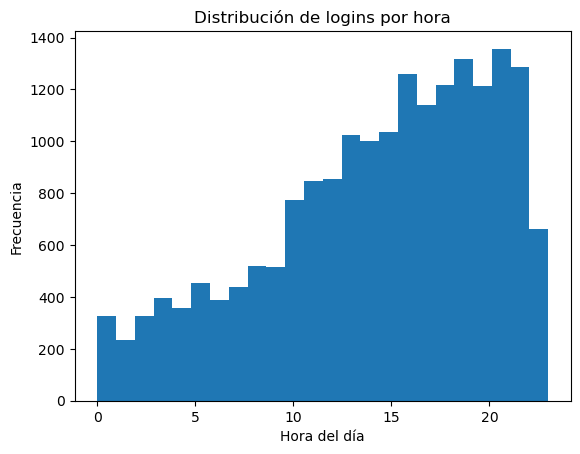

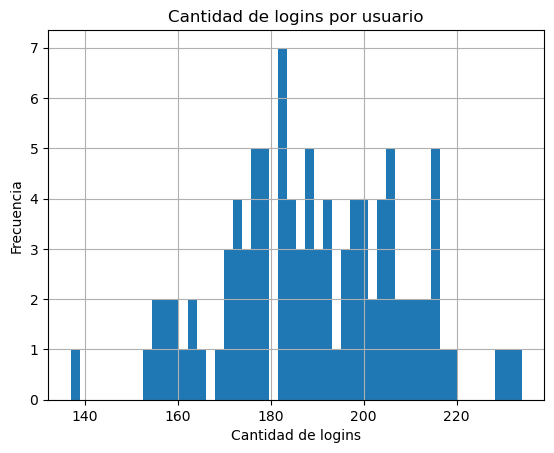

IPs únicas por usuario:
count    100.000000
mean      38.150000
std        5.774159
min       26.000000
25%       33.750000
50%       38.500000
75%       42.000000
max       51.000000
Name: ip_address, dtype: float64


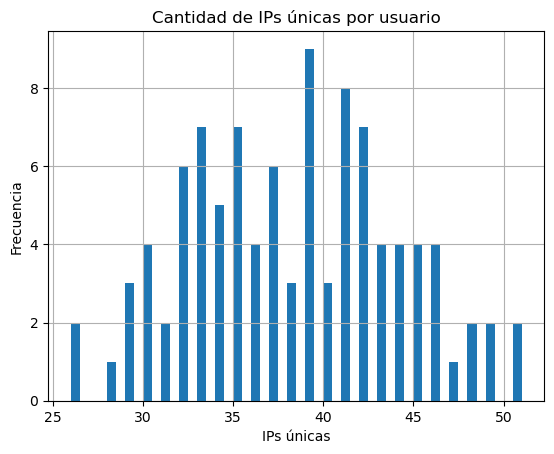

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest
from sklearn.metrics import classification_report

# ==========================================
# 📥 2. Carga de datos
# ==========================================
df = pd.read_csv(r'src\data\user_logins.csv')

df['login_time'] = pd.to_datetime(df['login_time'])
df = df.sort_values(['user_id', 'login_time'])

# ==========================================
# 🔍 3. EDA (Análisis Exploratorio de Datos)
# ==========================================

print(" Información general del dataset:")
print(df.info())

print("Estadísticas descriptivas:")
print(df.describe(include='all'))

# Distribución de logins por hora
plt.figure()
df['hour'] = df['login_time'].dt.hour
plt.hist(df['hour'], bins=24)
plt.title('Distribución de logins por hora')
plt.xlabel('Hora del día')
plt.ylabel('Frecuencia')
plt.show()

# Cantidad de logins por usuario
plt.figure()
df.groupby('user_id').size().hist(bins=50)
plt.title('Cantidad de logins por usuario')
plt.xlabel('Cantidad de logins')
plt.ylabel('Frecuencia')
plt.show()

# Análisis de IPs por usuario
ip_per_user = df.groupby('user_id')['ip_address'].nunique()
print("IPs únicas por usuario:")
print(ip_per_user.describe())

plt.figure()
ip_per_user.hist(bins=50)
plt.title('Cantidad de IPs únicas por usuario')
plt.xlabel('IPs únicas')
plt.ylabel('Frecuencia')
plt.show()
plt.show()

In [4]:
# ==========================================
# 🧪 UEBA Challenge - Problema 1 (A + B)
# Versión FINAL AJUSTADA - Lista para entrega
# Autor: Alexis Pacek
# ==========================================

# ==========================================
# 📦 1. Imports
# ==========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest
from sklearn.metrics import classification_report

# ==========================================
# 📥 2. Carga de datos
# ==========================================
df = pd.read_csv(r'src\data\user_logins.csv')

df['login_time'] = pd.to_datetime(df['login_time'])
df = df.sort_values(['user_id', 'login_time'])

# ==========================================
# 🔍 3. Feature Engineering
# ==========================================

# ⏰ Temporal
df['hour'] = df['login_time'].dt.hour
df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)

# ⚡ Tiempo entre logins
df['time_diff'] = df.groupby('user_id')['login_time'].diff().dt.total_seconds()
df['time_diff'] = df['time_diff'].fillna(df['time_diff'].median())
df['time_diff_log'] = np.log1p(df['time_diff'])

# 🌐 Rareza de IP
ip_counts = df.groupby(['user_id','ip_address']).size()
ip_freq = ip_counts / ip_counts.groupby(level=0).transform('sum')
df = df.join(ip_freq.rename('ip_freq'), on=['user_id','ip_address'])
df['ip_rarity'] = 1 - df['ip_freq']

# 💻 Rareza de dispositivo (se mantiene pero no será feature final)
device_counts = df.groupby(['user_id','device_type']).size()
device_freq = device_counts / device_counts.groupby(level=0).transform('sum')
df = df.join(device_freq.rename('device_freq'), on=['user_id','device_type'])
df['device_rarity'] = 1 - df['device_freq']

# 🔁 Cambio de IP
df['ip_change'] = (df['ip_address'] != df.groupby('user_id')['ip_address'].shift()).astype(int)

# 📊 Desvío horario (circular)
mean_sin = df.groupby('user_id')['hour_sin'].transform('mean')
mean_cos = df.groupby('user_id')['hour_cos'].transform('mean')
df['hour_deviation'] = np.sqrt((df['hour_sin']-mean_sin)**2 + (df['hour_cos']-mean_cos)**2)

# 🌐 IP compartidas (solo para derivados)
ip_user_count = df.groupby('ip_address')['user_id'].nunique()
df = df.join(ip_user_count.rename('ip_user_count'), on='ip_address')

# ==========================================
# 🧠 4. Features derivadas (AJUSTADAS)
# ==========================================

# Percentiles por usuario (robustos)
p90_ip = df.groupby('user_id')['ip_rarity'].transform(lambda x: x.quantile(0.90))
p5_time = df.groupby('user_id')['time_diff'].transform(lambda x: x.quantile(0.05))

# Anomalías fuertes
# Nota: relajamos ip_anomaly (p90) para que tenga señal

df['ip_anomaly'] = ((df['ip_rarity'] > p90_ip) & (df['ip_change'] == 1)).astype(int)
df['time_anomaly'] = (df['time_diff'] < p5_time).astype(int)
df['hour_anomaly'] = (df['hour_deviation'] > df['hour_deviation'].quantile(0.95)).astype(int)

# Consistencia de IP por usuario (comportamiento)
df['ip_consistency'] = df.groupby('user_id')['ip_address'].transform('nunique')

# Score combinado (señales principales)
df['risk_score'] = (
    df['time_anomaly'] +
    df['hour_anomaly'] +
    df['ip_anomaly']
)

# Label final (≥2 señales)
#df['label_rule'] = (df['risk_score'] >= 1).astype(int)
# En lugar de solo >= 1, podrías probar darles pesos:
df['risk_score_weighted'] = (
    2 * df['ip_anomaly'] +
    df['time_anomaly'] +
    df['hour_anomaly']
)

df['label_rule'] = (df['risk_score_weighted'] >= 2).astype(int)

print(f"% anomalías: {df['label_rule'].mean():.4%}")

print("Distribución de anomalías:")
print(df['label_rule'].value_counts(normalize=True))

# ==========================================
# 📊 5. Selección de features (FINAL)
# ==========================================

# Mantener solo features con señal demostrada
FEATURES = [
    'time_diff_log',
    'ip_rarity',
    'hour_deviation',
    'ip_consistency'
]

X = df[FEATURES].copy()  # asegurar nombres de columnas

# ==========================================
# 🤖 6. Modelo ML
# ==========================================

model = IsolationForest(contamination=df['label_rule'].mean(), random_state=42)
model.fit(X.values)
df['anomaly_ml'] = (model.predict(X.values) == -1).astype(int)

print("\nComparación modelo vs reglas:")
print(classification_report(df['label_rule'], df['anomaly_ml']))

# ==========================================
# 🔬 7. Importancia de features
# ==========================================

importance = df.groupby('label_rule')[FEATURES].mean().T
importance['diff'] = importance[1] - importance[0]

print("\nImportancia de features (ordenadas):")
print(importance.sort_values('diff', ascending=False))

# ==========================================
# 🔍 8. Ejemplos de anomalías (interpretabilidad)
# ==========================================

print("\nEjemplos de eventos anómalos:")
cols_show = [
    'user_id','login_time','ip_address','device_type',
    'time_diff','hour','ip_rarity','hour_deviation',
    'time_anomaly','hour_anomaly','ip_anomaly','risk_score'
]
print(df[df['label_rule'] == 1][cols_show].head(10))




% anomalías: 0.1584%
Distribución de anomalías:
0    0.998416
1    0.001584
Name: label_rule, dtype: float64

Comparación modelo vs reglas:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     18911
           1       0.17      0.17      0.17        30

    accuracy                           1.00     18941
   macro avg       0.58      0.58      0.58     18941
weighted avg       1.00      1.00      1.00     18941


Importancia de features (ordenadas):
label_rule              0          1      diff
ip_rarity        0.488506   0.896102  0.407596
hour_deviation   0.788969   1.150360  0.361391
time_diff_log    9.687786   6.232390 -3.455396
ip_consistency  38.316958  32.566667 -5.750292

Ejemplos de eventos anómalos:
       user_id          login_time       ip_address device_type  time_diff  \
1852   user_13 2024-09-05 21:00:00     192.168.1.16      tablet        0.0   
14117  user_21 2024-11-24 22:05:00     192.168.1.37     desktop        0.

Se desarrolló un sistema de detección de anomalías basado en reglas adaptadas por usuario, utilizando percentiles para capturar desviaciones en comportamiento temporal y uso de IP.

La etiqueta binaria se construyó combinando múltiples señales, priorizando eventos con mayor riesgo (como IPs raras y cambios de contexto).

El modelo de machine learning se utilizó como complemento para validar las reglas, observando limitaciones debido al desbalance del dataset.

Se descartó el uso de geolocalización debido al alto porcentaje de IPs privadas (~97%), lo que indica un entorno de red interna.